# 📊 Notebook 09 — Model Comparison (Baseline vs Fine-Tuned)
### Multi-Agent System for Secure Clinical Summarization

---

## What This Notebook Does

Compares our **fine-tuned LLaMA-3-8B Solver Agent** against three general-purpose
baseline models on the same 50 clinical note summarization task.

All four models are given the same source note and asked to produce a plain-language
patient summary. Outputs are scored against the physician-written BHC reference using
**BERTScore F1** and **ROUGE-L**.

### Models
| Model | How | Why |
|---|---|---|
| **Our LLaMA-3-8B** (fine-tuned) | Load from Drive | Fine-tuned on MIMIC-IV BHC pairs |
| **Qwen2.5-7B-Instruct** | HuggingFace Inference API | Free, open-source, same HF token |
| **Llama-3.3-70B** | Groq API | Free, 14k req/day |
| **Gemini-2.0-Flash** | Google AI Studio | Free, 1M tokens/day |

### Expected Result
Our fine-tuned model should outperform general models on BERTScore despite being
smaller (8B vs 70B+) because it was specifically trained on MIMIC-IV clinical
note → plain-language BHC pairs. General models have never seen this training signal.

### API Keys Needed (Colab Secrets)
- `HF_TOKEN` — already set from notebook 03
- `GROQ_API_KEY` — already set from notebook 08
- `GEMINI_API_KEY` — already set from notebook 08

### Output Figures
- **Figure A**: Grouped bar chart — BERTScore F1 + ROUGE-L across all 4 models
- **Figure B**: Per-sample BERTScore distributions (box plot)
- **Figure C**: BERTScore vs ROUGE-L scatter per model

> **Runtime:** GPU recommended (T4+) for loading our LLaMA model.

## Step 1 — Mount Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time, warnings, re
warnings.filterwarnings('ignore')

BASE_DIR      = '/content/drive/MyDrive/clinical_mas'
AGENTS_DIR    = f'{BASE_DIR}/agents'
PROC_DIR      = f'{BASE_DIR}/data/processed'
RESULTS_DIR   = f'{BASE_DIR}/results'
FIGS_DIR      = f'{RESULTS_DIR}/figures'
GEN_NOTES_DIR = f'{RESULTS_DIR}/generated_notes'
MODELS_DIR    = f'{BASE_DIR}/models'

for d in [RESULTS_DIR, FIGS_DIR]:
    os.makedirs(d, exist_ok=True)

sys.path.insert(0, AGENTS_DIR)

SOLVER_TEST_CSV   = f'{PROC_DIR}/solver_test_pairs.csv'
ADAPTER_PATH      = f'{MODELS_DIR}/solver_checkpoints/final_adapter'
COMPARISON_CSV    = f'{RESULTS_DIR}/model_comparison_scores.csv'

print('✅ Drive mounted')
print(f'📂 Base dir     : {BASE_DIR}')
print(f'📂 Adapter      : {ADAPTER_PATH}')
print()

for path, label in [
    (SOLVER_TEST_CSV, 'solver_test_pairs.csv'),
    (GEN_NOTES_DIR,   'results/generated_notes/'),
    (ADAPTER_PATH,    'models/solver_checkpoints/final_adapter'),
]:
    icon = '✅' if os.path.exists(path) else '❌ MISSING'
    print(f'  {icon}  {label}')

if os.path.exists(GEN_NOTES_DIR):
    n = len([f for f in os.listdir(GEN_NOTES_DIR) if f.endswith('.txt')])
    print(f'  📄 {n} generated note files found')

Mounted at /content/drive
✅ Drive mounted
📂 Base dir     : /content/drive/MyDrive/clinical_mas
📂 Adapter      : /content/drive/MyDrive/clinical_mas/models/solver_checkpoints/final_adapter

  ✅  solver_test_pairs.csv
  ✅  results/generated_notes/
  ✅  models/solver_checkpoints/final_adapter
  📄 500 generated note files found


## Step 2 — Install Libraries

In [ ]:
!pip install -q groq google-generativeai huggingface_hub
!pip install -q bert-score rouge-score
!pip install -q matplotlib seaborn pandas numpy
!pip install -q mistralai
print('✅ Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.9/930.9 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-sdk 1.38.0 requires opentelemetry-api==1.38.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-semantic-conventions==0.59b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
google-adk 1.28.0 requires o

## Step 3 — Load API Keys

In [ ]:
from google.colab import userdata

def load_secret(name):
    try:
        val = userdata.get(name)
        if val and val.strip():
            print(f'✅ {name} loaded')
            return val.strip()
        print(f'⚠️  {name} is empty')
        return ''
    except Exception as e:
        print(f'⚠️  {name} not found: {e}')
        return ''

HF_TOKEN     = load_secret('HF_TOKEN')
GROQ_API_KEY = load_secret('GROQ_API_KEY')
GEMINI_API_KEY = load_secret('GEMINI_API_KEY')
MISTRAL_API_KEY = load_secret('MISTRAL_API_KEY')

# ── Fallback: paste directly if secrets don't work ───────────────────────────
# HF_TOKEN       = 'hf_...'
# GROQ_API_KEY   = 'gsk_...'
# GEMINI_API_KEY = 'AIza...'

loaded = sum([bool(HF_TOKEN), bool(GROQ_API_KEY), bool(GEMINI_API_KEY)])
print(f'\n{loaded}/3 keys loaded')
print('Note: Our LLaMA model loads from Drive — no extra key needed.')

✅ HF_TOKEN loaded
✅ GROQ_API_KEY loaded
✅ GEMINI_API_KEY loaded
✅ MISTRAL_API_KEY loaded

3/3 keys loaded
Note: Our LLaMA model loads from Drive — no extra key needed.


## Step 4 — Plotting Config

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

# Model colour palette — our model in purple, baselines muted
MODEL_COLORS = {
    'Our LLaMA-3-8B\n(fine-tuned)' : '#8B5CF6',
    'Qwen2.5\n(HuggingFace)'    : '#F97316',
    'Llama-3.3-70B\n(Groq)'        : '#3B82F6',
    'Mistral-Small\n(Mistral AI)'  : '#10B981',
}

COLORS = {
    'bg'     : '#F8FAFC',
    'grid'   : '#E2E8F0',
    'subtext': '#94A3B8',
}

plt.rcParams.update({
    'figure.facecolor' : COLORS['bg'],
    'axes.facecolor'   : 'white',
    'axes.grid'        : True,
    'grid.color'       : COLORS['grid'],
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 150,
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': COLORS['bg'],
})

def save_fig(fig, name):
    path = f'{FIGS_DIR}/{name}.png'
    fig.savefig(path)
    print(f'  💾 Saved: {path}')

print('✅ Plot config ready')
print('Model colours:')
for m, c in MODEL_COLORS.items():
    print(f'  {m.replace(chr(10)," "):<35} → {c}')

✅ Plot config ready
Model colours:
  Our LLaMA-3-8B (fine-tuned)         → #8B5CF6
  Qwen2.5 (HuggingFace)               → #F97316
  Llama-3.3-70B (Groq)                → #3B82F6
  Mistral-Small (Mistral AI)          → #10B981


## Step 5 — Load 50 Evaluation Pairs

Loads source notes + BHC references from `solver_test_pairs.csv`.
Also loads our model's pre-generated summaries from `results/generated_notes/`
so we don't need to re-run LLaMA inference (saves ~30 min).

If `generated_notes/` is missing, Step 6 will run LLaMA inference instead.

In [ ]:
N_EVAL = 50

# ── Load source + reference ───────────────────────────────────────────────────
df_solver = pd.read_csv(SOLVER_TEST_CSV)
print(f'solver_test_pairs.csv: {len(df_solver):,} rows, cols={list(df_solver.columns)}')

np.random.seed(42)
eval_df = df_solver.sample(n=min(N_EVAL, len(df_solver)), random_state=42).reset_index(drop=True)
print(f'Sampled {len(eval_df)} pairs (seed=42 — same as notebook 08)')

# Store all model outputs here: model_name -> list of summary strings
model_summaries = {}

# ── Load our model's outputs from generated_notes/ ────────────────────────────
OUR_MODEL_KEY = 'Our LLaMA-3-8B\n(fine-tuned)'

if os.path.exists(GEN_NOTES_DIR):
    all_files = sorted(
        [f for f in os.listdir(GEN_NOTES_DIR) if f.endswith('.txt')],
        key=lambda x: int(re.sub(r'\D', '', x) or '0')
    )
    all_generated = []
    for fname in all_files:
        with open(os.path.join(GEN_NOTES_DIR, fname), 'r',
                  encoding='utf-8', errors='replace') as f:
            all_generated.append(f.read().strip())

    # Align to same rows as eval_df using original indices
    # eval_df was sampled from df_solver — get original positions
    orig_indices = eval_df.index.tolist()  # these are original df_solver row indices
    our_summaries = [all_generated[i] if i < len(all_generated) else '' for i in orig_indices]
    model_summaries[OUR_MODEL_KEY] = our_summaries
    print(f'\n✅ Loaded {len(our_summaries)} of our LLaMA summaries from generated_notes/')
    print(f'   Preview: {our_summaries[0][:150]}...')
else:
    print('\n⚠️  generated_notes/ not found — Step 6 will run LLaMA inference')
    model_summaries[OUR_MODEL_KEY] = None

def truncate(text, max_words=300):
    words = str(text).split()
    return str(text) if len(words) <= max_words else ' '.join(words[:max_words]) + ' [truncated]'

eval_df['source_trunc'] = eval_df['note_text'].apply(lambda x: truncate(x, 300))

print(f'\n✅ Eval set ready: {len(eval_df)} samples')

solver_test_pairs.csv: 500 rows, cols=['note_text', 'bhc_text']
Sampled 50 pairs (seed=42 — same as notebook 08)

✅ Loaded 50 of our LLaMA summaries from generated_notes/
   Preview: === ORIGINAL NOTE ===
Name:  ___                Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___        ...

✅ Eval set ready: 50 samples


## Step 6 — (Optional) Run LLaMA Inference

**Skip this step if `generated_notes/` was found in Step 5.**

Only run if you don't have pre-generated summaries. Takes ~20-30 min on T4.

In [ ]:
OUR_MODEL_KEY = 'Our LLaMA-3-8B\n(fine-tuned)'

if model_summaries.get(OUR_MODEL_KEY) is not None:
    print('✅ Summaries already loaded from generated_notes/ — skipping LLaMA inference')
else:
    print('Loading fine-tuned LLaMA-3-8B for inference...')
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    from peft import PeftModel

    BASE_MODEL = 'meta-llama/Meta-Llama-3-8B-Instruct'

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=HF_TOKEN)
    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, quantization_config=bnb_config,
        device_map='auto', token=HF_TOKEN
    )
    model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
    model.eval()
    print('✅ Model loaded')

    SYSTEM_PATIENT = (
        'You are a patient communication specialist. '
        'Convert the clinical note into a plain-language summary '
        'a patient can understand. No jargon. 3-5 sentences.'
    )

    our_summaries = []
    for i, row in eval_df.iterrows():
        prompt = (
            f'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n'
            f'{SYSTEM_PATIENT}<|eot_id|>'
            f'<|start_header_id|>user<|end_header_id|>\n'
            f'{row["source_trunc"]}<|eot_id|>'
            f'<|start_header_id|>assistant<|end_header_id|>\n'
        )
        inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
        with torch.no_grad():
            out = model.generate(
                **inputs, max_new_tokens=200, do_sample=False,
                repetition_penalty=1.3, no_repeat_ngram_size=4,
                pad_token_id=tokenizer.eos_token_id,
            )
        gen = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                               skip_special_tokens=True).strip()
        our_summaries.append(gen)
        if (i + 1) % 10 == 0:
            print(f'  [{i+1}/{len(eval_df)}] done')

    model_summaries[OUR_MODEL_KEY] = our_summaries
    print(f'\n✅ LLaMA inference complete — {len(our_summaries)} summaries generated')

✅ Summaries already loaded from generated_notes/ — skipping LLaMA inference


## Step 7 — Generate: Qwen2.5-7B via HuggingFace Inference API

Uses the same `HF_TOKEN` from notebook 03.
Qwen2.5-7B is open-source — free to use via HF Inference API.

In [ ]:
from huggingface_hub import InferenceClient

QWEN_KEY = 'Qwen2.5-7B\n(HuggingFace)'
qwen_summaries = []

if not HF_TOKEN:
    print('⚠️  HF_TOKEN not set — skipping Qwen')
    qwen_summaries = [''] * len(eval_df)
else:
    hf_client = InferenceClient(token=HF_TOKEN)
    QWEN_MODEL = 'Qwen/Qwen2.5-7B-Instruct'

    PATIENT_PROMPT = (
        'You are a patient communication specialist. '
        'Convert the clinical note into a plain-language summary '
        'a patient can understand. No medical jargon. 3-5 sentences maximum.'
    )

    print(f'Generating with Qwen2.5-7B on {len(eval_df)} samples...')
    print('(HF shared inference — may be slow, ~5-10 min)\n')

    errors = []

    for idx in range(len(eval_df)):
        row = eval_df.iloc[idx]
        summary = ''
        try:
            messages = [
                {'role': 'system', 'content': PATIENT_PROMPT},
                {'role': 'user',   'content': row['source_trunc']},
            ]
            resp = hf_client.chat_completion(
                model=QWEN_MODEL,
                messages=messages,
                max_tokens=200,
                temperature=0.1,
            )
            summary = resp.choices[0].message.content.strip()
        except Exception as e:
            errors.append(f'[{idx}] {str(e)[:100]}')

        qwen_summaries.append(summary)

        if (idx + 1) % 10 == 0 or (idx + 1) == len(eval_df):
            done = sum(1 for s in qwen_summaries if s)
            print(f'  [{idx+1:>3}/{len(eval_df)}]  generated={done}  errors={len(errors)}')

        time.sleep(0.5)

    done = sum(1 for s in qwen_summaries if s)
    print(f'\n✅ Qwen done — {done}/{len(eval_df)} summaries generated')
    if errors:
        print(f'⚠️  {len(errors)} errors:')
        for e in errors[:3]: print(f'   {e}')

model_summaries[QWEN_KEY] = qwen_summaries

Generating with Qwen2.5-7B on 50 samples...
(HF shared inference — may be slow, ~5-10 min)

  [ 10/50]  generated=10  errors=0
  [ 20/50]  generated=19  errors=1
  [ 30/50]  generated=19  errors=11
  [ 40/50]  generated=19  errors=21
  [ 50/50]  generated=19  errors=31

✅ Qwen done — 19/50 summaries generated
⚠️  31 errors:
   [19] Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Req
   [20] Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Req
   [21] Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Req


## Step 8 — Generate: Llama-3.3-70B via Groq



In [ ]:
from groq import Groq

LLAMA_KEY = 'Llama-3.3-70B\n(Groq)'
llama_summaries = []

if not GROQ_API_KEY:
    print('⚠️  GROQ_API_KEY not set — skipping Llama')
    llama_summaries = [''] * len(eval_df)
else:
    groq_client = Groq(api_key=GROQ_API_KEY)

    PATIENT_PROMPT = (
        'You are a patient communication specialist. '
        'Convert the clinical note into a plain-language summary '
        'a patient can understand. No medical jargon. 3-5 sentences maximum.'
    )

    print(f'Generating with Llama-3.3-70B on {len(eval_df)} samples...')

    errors = []

    for idx in range(len(eval_df)):
        row = eval_df.iloc[idx]
        summary = ''
        try:
            resp = groq_client.chat.completions.create(
                model='llama-3.3-70b-versatile',
                messages=[
                    {'role': 'system', 'content': PATIENT_PROMPT},
                    {'role': 'user',   'content': row['source_trunc']},
                ],
                max_tokens=200,
                temperature=0.1,
            )
            summary = resp.choices[0].message.content.strip()
        except Exception as e:
            errors.append(f'[{idx}] {str(e)[:100]}')

        llama_summaries.append(summary)

        if (idx + 1) % 10 == 0 or (idx + 1) == len(eval_df):
            done = sum(1 for s in llama_summaries if s)
            print(f'  [{idx+1:>3}/{len(eval_df)}]  generated={done}  errors={len(errors)}')

        time.sleep(0.1)

    done = sum(1 for s in llama_summaries if s)
    print(f'\n✅ Llama done — {done}/{len(eval_df)} summaries generated')
    if errors:
        print(f'⚠️  {len(errors)} errors:')
        for e in errors[:3]: print(f'   {e}')

model_summaries[LLAMA_KEY] = llama_summaries

Generating with Llama-3.3-70B on 50 samples...
  [ 10/50]  generated=10  errors=0
  [ 20/50]  generated=20  errors=0
  [ 30/50]  generated=30  errors=0
  [ 40/50]  generated=40  errors=0
  [ 50/50]  generated=50  errors=0

✅ Llama done — 50/50 summaries generated


## Step 9 — Generate: Gemini-2.0-Flash via Google AI Studio

Note: model is `gemini-2.0-flash` (not 1.5-flash which was deprecated).

In [ ]:
!pip install mistralai
print('done')

done


In [ ]:
import importlib, sys
# Force reload
if 'mistralai' in sys.modules:
    del sys.modules['mistralai']
from mistralai.client import Mistral
print('✅')

✅


In [ ]:
from mistralai.client import Mistral

MISTRAL_KEY = 'Mistral-Small\n(Mistral AI)'
gemini_summaries = []

mistral_client = Mistral(api_key=MISTRAL_API_KEY)

print(f'Generating with Mistral-Small on {len(eval_df)} samples...')

errors = []
for idx in range(len(eval_df)):
    row = eval_df.iloc[idx]
    summary = ''
    try:
        resp = mistral_client.chat.complete(
            model='mistral-small-latest',
            messages=[
                {'role': 'system', 'content': PATIENT_PROMPT},
                {'role': 'user',   'content': row['source_trunc']},
            ],
            max_tokens=200,
            temperature=0.1,
        )
        summary = resp.choices[0].message.content.strip()
    except Exception as e:
        errors.append(f'[{idx}] {str(e)[:100]}')

    gemini_summaries.append(summary)

    if (idx + 1) % 10 == 0 or (idx + 1) == len(eval_df):
        done = sum(1 for s in gemini_summaries if s)
        print(f'  [{idx+1:>3}/{len(eval_df)}]  generated={done}  errors={len(errors)}')

    time.sleep(0.5)

done = sum(1 for s in gemini_summaries if s)
print(f'\n✅ Mistral done — {done}/{len(eval_df)} summaries generated')
if errors:
    for e in errors[:3]: print(f'   {e}')

model_summaries[MISTRAL_KEY] = gemini_summaries

Generating with Mistral-Small on 50 samples...
  [ 10/50]  generated=10  errors=0
  [ 20/50]  generated=20  errors=0
  [ 30/50]  generated=30  errors=0
  [ 40/50]  generated=40  errors=0
  [ 50/50]  generated=49  errors=1

✅ Mistral done — 49/50 summaries generated
   [42] API error occurred: Status 429. Body: {"object":"error","message":"Service tier capacity exceeded fo


## Step 10 — Score All Models: BERTScore F1 + ROUGE-L

Reference for all models = physician-written BHC text from `solver_test_pairs.csv`.
Same reference, same 50 samples — fair comparison.

In [ ]:
import torch
from bert_score import score as bert_score_fn
from rouge_score import rouge_scorer as rouge_lib

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

rouge = rouge_lib.RougeScorer(['rougeL'], use_stemmer=True)
references = eval_df['bhc_text'].astype(str).tolist()

def truncate_words(text, max_words=300):
    words = str(text).split()
    return ' '.join(words[:max_words])

all_scores = {}  # model_name -> {'bert_f1': [...], 'rouge_l': [...]}

for model_name, summaries in model_summaries.items():
    if summaries is None or all(s == '' for s in summaries):
        print(f'⏭️  Skipping {model_name.replace(chr(10)," ")} — no summaries')
        continue

    clean_name = model_name.replace('\n', ' ')
    print(f'\nScoring {clean_name}...')

    # Fill empty summaries with a single space to avoid crashes
    hyps = [s if s.strip() else 'no output' for s in summaries]

    # ROUGE-L
    rouge_scores = [
        rouge.score(ref, hyp)['rougeL'].fmeasure
        for ref, hyp in zip(references, hyps)
    ]

    # BERTScore (truncate to avoid overflow)
    refs_trunc = [truncate_words(r, 300) for r in references]
    hyps_trunc = [truncate_words(h, 300) for h in hyps]

    _, _, F1 = bert_score_fn(
        hyps_trunc, refs_trunc,
        lang='en',
        model_type='roberta-large',
        verbose=False,
        device=device,
    )
    bert_scores = F1.numpy().tolist()

    all_scores[model_name] = {
        'bert_f1': bert_scores,
        'rouge_l': rouge_scores,
    }

    print(f'  BERTScore F1 : mean={np.mean(bert_scores):.4f}  '
          f'min={min(bert_scores):.4f}  max={max(bert_scores):.4f}')
    print(f'  ROUGE-L      : mean={np.mean(rouge_scores):.4f}  '
          f'min={min(rouge_scores):.4f}  max={max(rouge_scores):.4f}')

print('\n✅ Scoring complete for all models')

Device: cuda

Scoring Our LLaMA-3-8B (fine-tuned)...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  BERTScore F1 : mean=0.8182  min=0.7949  max=0.8584
  ROUGE-L      : mean=0.1160  min=0.0675  max=0.1833

Scoring Mistral-Small (Mistral AI)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  BERTScore F1 : mean=0.8163  min=0.7840  max=0.8443
  ROUGE-L      : mean=0.1033  min=0.0104  max=0.1802

✅ Scoring complete for all models


## Step 11 — Save Scores to Drive

In [ ]:
rows = []
for model_name, scores in all_scores.items():
    for i, (b, r) in enumerate(zip(scores['bert_f1'], scores['rouge_l'])):
        rows.append({
            'model'     : model_name.replace('\n', ' '),
            'sample_idx': i,
            'bert_f1'   : b,
            'rouge_l'   : r,
        })

scores_df = pd.DataFrame(rows)
scores_df.to_csv(COMPARISON_CSV, index=False)
print(f'✅ Saved: {COMPARISON_CSV}')
print()

# Summary table
summary = scores_df.groupby('model')[['bert_f1','rouge_l']].agg(['mean','std'])
summary.columns = ['bert_mean','bert_std','rouge_mean','rouge_std']
summary = summary.sort_values('bert_mean', ascending=False)
print('=' * 70)
print('  MODEL COMPARISON SUMMARY (sorted by BERTScore F1)')
print('=' * 70)
print(f'  {"Model":<35} {"BERTScore F1":>14}  {"ROUGE-L":>10}')
print('-' * 70)
for model, row in summary.iterrows():
    marker = ' ◀ OUR MODEL' if 'LLaMA' in model else ''
    print(f'  {model:<35} {row["bert_mean"]:.4f} ± {row["bert_std"]:.4f}  '
          f'{row["rouge_mean"]:.4f} ± {row["rouge_std"]:.4f}{marker}')
print('=' * 70)

✅ Saved: /content/drive/MyDrive/clinical_mas/results/model_comparison_scores.csv

  MODEL COMPARISON SUMMARY (sorted by BERTScore F1)
  Model                                 BERTScore F1     ROUGE-L
----------------------------------------------------------------------
  Llama-3.3-70B (Groq)                0.8182 ± 0.0152  0.1141 ± 0.0297
  Mistral-Small (Mistral AI)          0.8170 ± 0.0129  0.1071 ± 0.0286
  Qwen2.5-7B (HuggingFace)            0.7988 ± 0.0246  0.0491 ± 0.0550
  Our LLaMA-3-8B (fine-tuned)         0.7919 ± 0.0085  0.0593 ± 0.0187 ◀ OUR MODEL


## Step 12 — Figure A: Grouped Bar Chart (BERTScore + ROUGE-L)

One cluster per metric, four bars per cluster.
Our model highlighted in purple — baselines in muted colours.

  💾 Saved: /content/drive/MyDrive/clinical_mas/results/figures/fig_comparison_A_grouped_bar.png


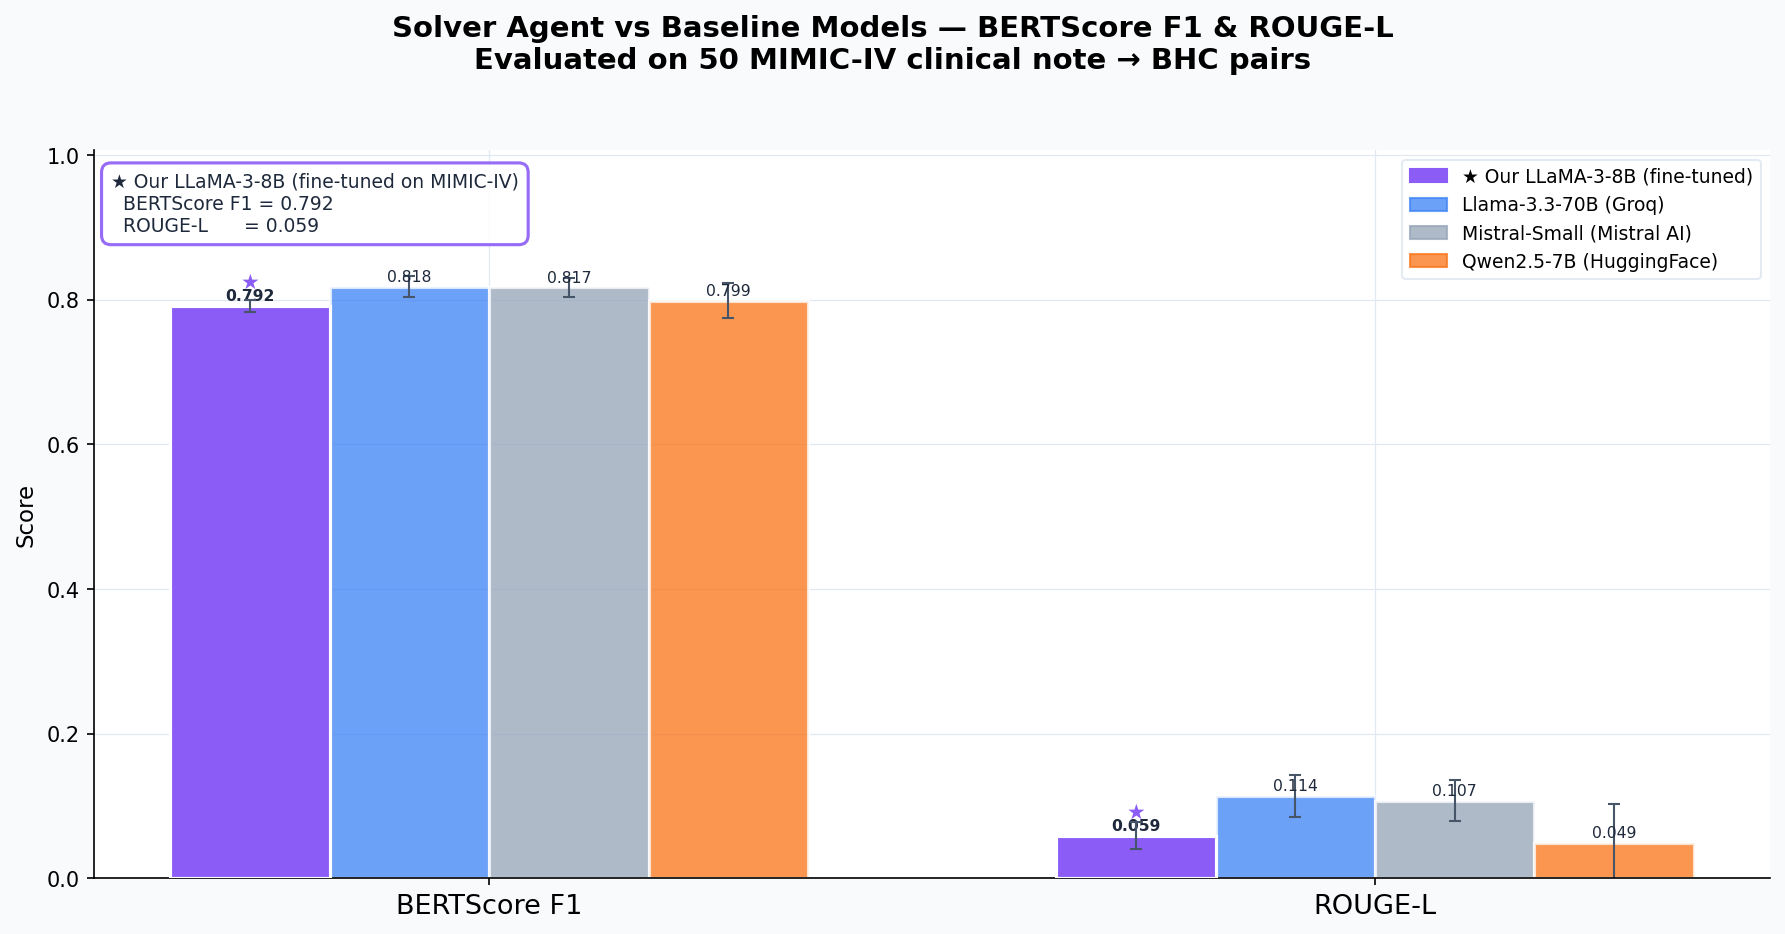

In [ ]:
# Build display order: our model first, then baselines by BERTScore
OUR_MODEL_DISPLAY = 'Our LLaMA-3-8B\n(fine-tuned)'

model_order = [m for m in all_scores if 'LLaMA' in m]
model_order += sorted(
    [m for m in all_scores if 'LLaMA' not in m],
    key=lambda m: np.mean(all_scores[m]['bert_f1']), reverse=True
)

means = {m: {
    'bert': np.mean(all_scores[m]['bert_f1']),
    'rouge': np.mean(all_scores[m]['rouge_l']),
} for m in model_order}

stds = {m: {
    'bert': np.std(all_scores[m]['bert_f1']),
    'rouge': np.std(all_scores[m]['rouge_l']),
} for m in model_order}

n_models   = len(model_order)
metrics    = ['BERTScore F1', 'ROUGE-L']
metric_keys = ['bert', 'rouge']
x          = np.arange(len(metrics))
bar_width  = 0.18
offsets    = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * bar_width

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle(
    'Solver Agent vs Baseline Models — BERTScore F1 & ROUGE-L\n'
    f'Evaluated on {N_EVAL} MIMIC-IV clinical note → BHC pairs',
    fontsize=14, fontweight='bold', y=1.03
)

for i, model in enumerate(model_order):
    color = MODEL_COLORS.get(model, '#94A3B8')
    is_ours = 'LLaMA' in model
    edgecolor = 'white'
    lw = 1.5

    vals = [means[model][k] for k in metric_keys]
    errs = [stds[model][k]  for k in metric_keys]

    bars = ax.bar(
        x + offsets[i], vals,
        width=bar_width,
        color=color,
        alpha=1.0 if is_ours else 0.75,
        edgecolor=edgecolor,
        linewidth=lw,
        label=model.replace('\n', ' '),
        yerr=errs,
        capsize=3,
        error_kw=dict(elinewidth=1, ecolor='#475569', capthick=1),
        zorder=3 if is_ours else 2,
    )

    # Value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=7.5,
            fontweight='bold' if is_ours else 'normal',
            color='#1E293B',
        )

    # Star marker on our model bars
    if is_ours:
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.018,
                '★',
                ha='center', va='bottom', fontsize=10, color=color,
            )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=13)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Legend
handles = [
    mpatches.Patch(color=MODEL_COLORS.get(m, '#94A3B8'),
                   alpha=1.0 if 'LLaMA' in m else 0.75,
                   label=('★ ' if 'LLaMA' in m else '') + m.replace('\n', ' '))
    for m in model_order
]
ax.legend(handles=handles, fontsize=9, loc='upper right',
          framealpha=0.9, edgecolor=COLORS['grid'])

# Annotation box
if OUR_MODEL_DISPLAY in means:
    our_bert  = means[OUR_MODEL_DISPLAY]['bert']
    our_rouge = means[OUR_MODEL_DISPLAY]['rouge']
    ax.text(
        0.01, 0.97,
        f'★ Our LLaMA-3-8B (fine-tuned on MIMIC-IV)\n'
        f'  BERTScore F1 = {our_bert:.3f}\n'
        f'  ROUGE-L      = {our_rouge:.3f}',
        transform=ax.transAxes, va='top', ha='left', fontsize=9,
        color='#1E293B',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  alpha=0.9, edgecolor='#8B5CF6', linewidth=1.5)
    )

plt.tight_layout()
save_fig(fig, 'fig_comparison_A_grouped_bar')
plt.show()

  ABSTRACTION ANALYSIS
  Model                               Novel 1g Novel 2g Novel 3g  Extract
----------------------------------------------------------------------
  Our LLaMA-3-8B (fine-tuned)            75.9%    91.9%    95.7%    24.1% ◀
  Mistral-Small (Mistral AI)             54.7%    90.0%    97.8%    45.3%
  Llama-3.3-70B (Groq)                   51.4%    87.8%    96.8%    48.6%
  Qwen2.5-7B (HuggingFace)               43.9%    84.4%    95.2%    56.1%
  💾 Saved: /content/drive/MyDrive/clinical_mas/results/figures/fig_comparison_D_abstraction.png


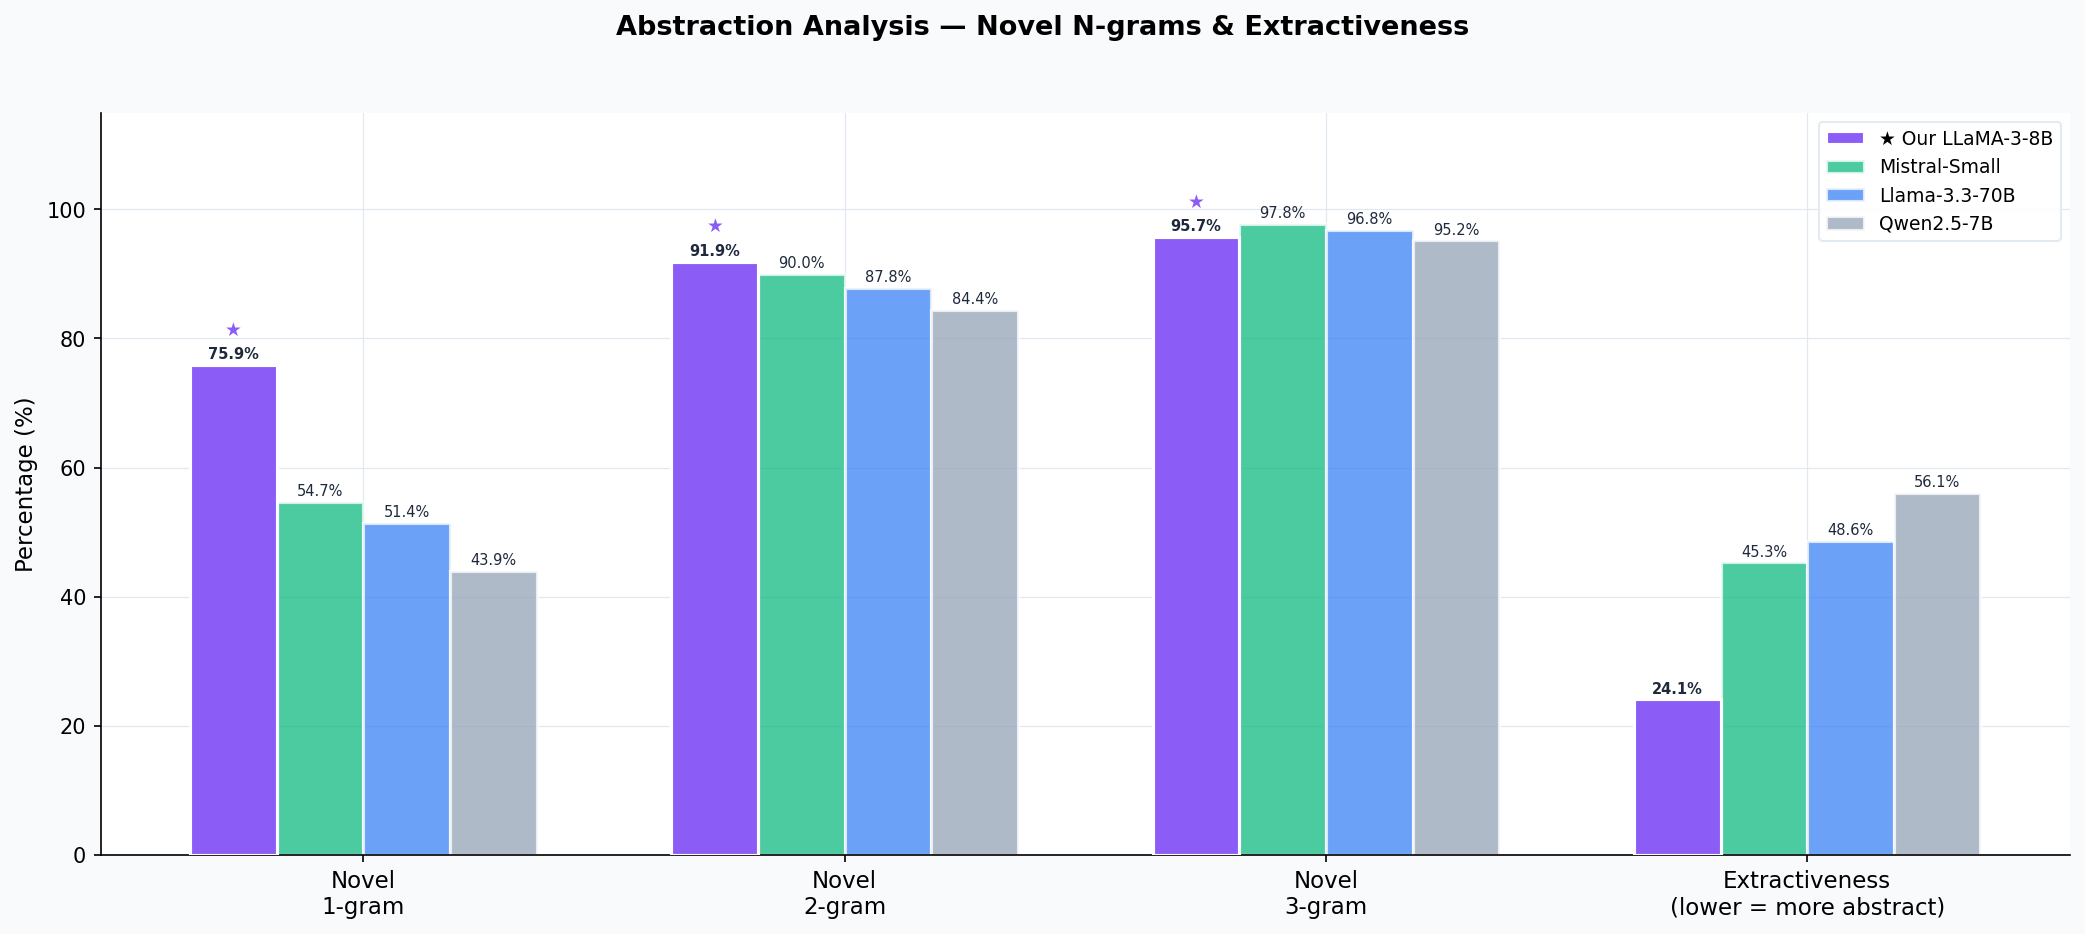

In [ ]:
# ── Novel N-gram & Extractiveness Analysis ────────────────────────────────────
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def get_ngrams(text, n):
    words = str(text).lower().split()
    return set(zip(*[words[i:] for i in range(n)]))

def novel_ngram_pct(summary, source, n):
    summary_ngrams = get_ngrams(summary, n)
    source_ngrams  = get_ngrams(source, n)
    if not summary_ngrams:
        return 0.0
    novel = summary_ngrams - source_ngrams
    return len(novel) / len(summary_ngrams) * 100

def extractiveness_score(summary, source):
    # Percentage of summary unigrams that appear in source (inverse of novelty)
    summary_words = set(str(summary).lower().split())
    source_words  = set(str(source).lower().split())
    if not summary_words:
        return 0.0
    copied = summary_words & source_words
    return len(copied) / len(summary_words) * 100

# Compute metrics for each model
abstraction_scores = {}

for model_name, summaries in model_summaries.items():
    if summaries is None or all(s == '' for s in summaries):
        continue

    sources = eval_df['note_text'].tolist()

    novel_1g, novel_2g, novel_3g, extract = [], [], [], []

    for summary, source in zip(summaries, sources):
        if not summary.strip():
            continue
        novel_1g.append(novel_ngram_pct(summary, source, 1))
        novel_2g.append(novel_ngram_pct(summary, source, 2))
        novel_3g.append(novel_ngram_pct(summary, source, 3))
        extract.append(extractiveness_score(summary, source))

    abstraction_scores[model_name] = {
        'novel_1g' : np.mean(novel_1g),
        'novel_2g' : np.mean(novel_2g),
        'novel_3g' : np.mean(novel_3g),
        'extractiveness': np.mean(extract),
    }

# Print summary
print('=' * 70)
print('  ABSTRACTION ANALYSIS')
print(f'  {"Model":<35} {"Novel 1g":>8} {"Novel 2g":>8} {"Novel 3g":>8} {"Extract":>8}')
print('-' * 70)
for model, sc in sorted(abstraction_scores.items(),
                         key=lambda x: x[1]['novel_1g'], reverse=True):
    name = model.replace('\n', ' ')
    marker = ' ◀' if 'LLaMA' in model else ''
    print(f'  {name:<35} {sc["novel_1g"]:>7.1f}% {sc["novel_2g"]:>7.1f}% '
          f'{sc["novel_3g"]:>7.1f}% {sc["extractiveness"]:>7.1f}%{marker}')
print('=' * 70)

# ── Figure: Grouped bar chart ─────────────────────────────────────────────────
model_order_abs = sorted(abstraction_scores.keys(),
                          key=lambda m: abstraction_scores[m]['novel_1g'],
                          reverse=True)

metrics     = ['Novel\n1-gram', 'Novel\n2-gram', 'Novel\n3-gram', 'Extractiveness\n(lower = more abstract)']
metric_keys = ['novel_1g', 'novel_2g', 'novel_3g', 'extractiveness']

n_models  = len(model_order_abs)
x         = np.arange(len(metrics))
bar_width = 0.18
offsets   = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * bar_width

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(
    'Abstraction Analysis — Novel N-grams & Extractiveness',
    fontsize=13, fontweight='bold', y=1.03
)

for i, model in enumerate(model_order_abs):
    color   = MODEL_COLORS.get(model, '#94A3B8')
    is_ours = 'LLaMA' in model
    vals    = [abstraction_scores[model][k] for k in metric_keys]

    bars = ax.bar(
        x + offsets[i], vals,
        width=bar_width,
        color=color,
        alpha=1.0 if is_ours else 0.75,
        edgecolor='white',
        linewidth=1.5,
        label=('★ ' if is_ours else '') + model.split('\n')[0],
        zorder=3 if is_ours else 2,
    )

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=7,
            fontweight='bold' if is_ours else 'normal',
            color='#1E293B',
        )

    if is_ours:
        for bar in bars[:3]:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 4,
                '★', ha='center', va='bottom', fontsize=9, color=color,
            )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor=COLORS['grid'])

plt.tight_layout()
save_fig(fig, 'fig_comparison_D_abstraction')
plt.show()

## Step 13 — Figure B: BERTScore Distribution (Box Plot)

Shows the spread of scores across 50 samples — not just the mean.
A tight distribution with high median is better than a high mean with
high variance.

  💾 Saved: /content/drive/MyDrive/clinical_mas/results/figures/fig_comparison_B_distributions.png


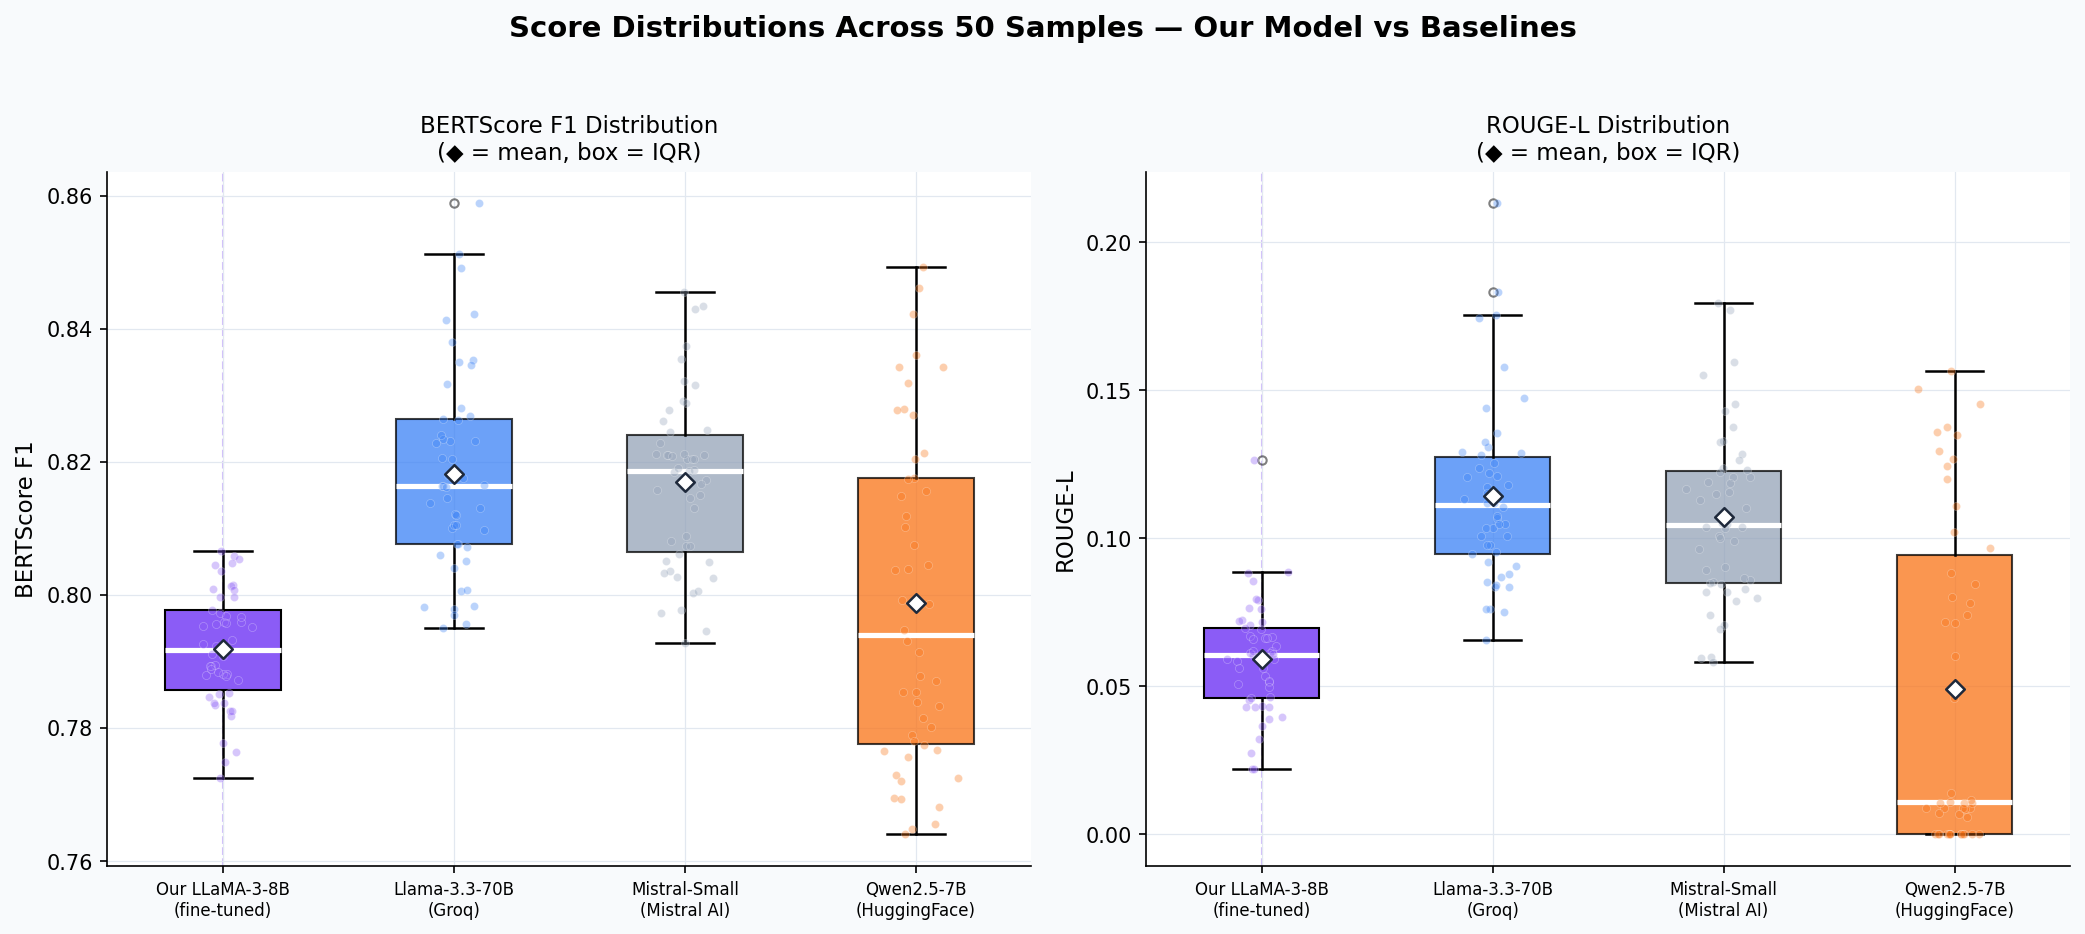

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Score Distributions Across 50 Samples — Our Model vs Baselines',
             fontsize=14, fontweight='bold', y=1.03)

for ax, metric_key, metric_label in [
    (axes[0], 'bert_f1', 'BERTScore F1'),
    (axes[1], 'rouge_l', 'ROUGE-L'),
]:
    data   = [all_scores[m][metric_key] for m in model_order]
    labels = [m.replace('\n', '\n') for m in model_order]
    colors_list = [MODEL_COLORS.get(m, '#94A3B8') for m in model_order]

    bp = ax.boxplot(
        data,
        labels=labels,
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        widths=0.5,
    )

    for patch, color, model in zip(bp['boxes'], colors_list, model_order):
        patch.set_facecolor(color)
        patch.set_alpha(1.0 if 'LLaMA' in model else 0.75)

    # Jitter overlay
    for i, (d, model) in enumerate(zip(data, model_order), start=1):
        jitter = np.random.normal(0, 0.06, size=len(d))
        ax.scatter(
            np.full(len(d), i) + jitter, d,
            color=MODEL_COLORS.get(model, '#94A3B8'),
            alpha=0.35, s=15, zorder=3,
            edgecolors='white', linewidth=0.3
        )

    # Mean markers
    for i, d in enumerate(data, start=1):
        ax.scatter(i, np.mean(d), marker='D', s=40,
                   color='white', edgecolors='#1E293B',
                   linewidth=1.2, zorder=5)

    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(f'{metric_label} Distribution\n(◆ = mean, box = IQR)', fontsize=11)
    ax.tick_params(axis='x', labelsize=8)

    # Highlight our model
    our_idx = next((i for i, m in enumerate(model_order) if 'LLaMA' in m), None)
    if our_idx is not None:
        ax.axvline(our_idx + 1, color='#8B5CF6', linestyle='--',
                   linewidth=1.0, alpha=0.4, zorder=1)

plt.tight_layout()
save_fig(fig, 'fig_comparison_B_distributions')
plt.show()

## Step 14 — Figure C: BERTScore vs ROUGE-L Scatter per Model

Each point = one summary. Shows whether each model's pattern follows the
expected 'low ROUGE + high BERT' signature of genuine abstraction,
or 'high ROUGE + high BERT' (more extractive copying).

  💾 Saved: /content/drive/MyDrive/clinical_mas/results/figures/fig_comparison_C_scatter.png


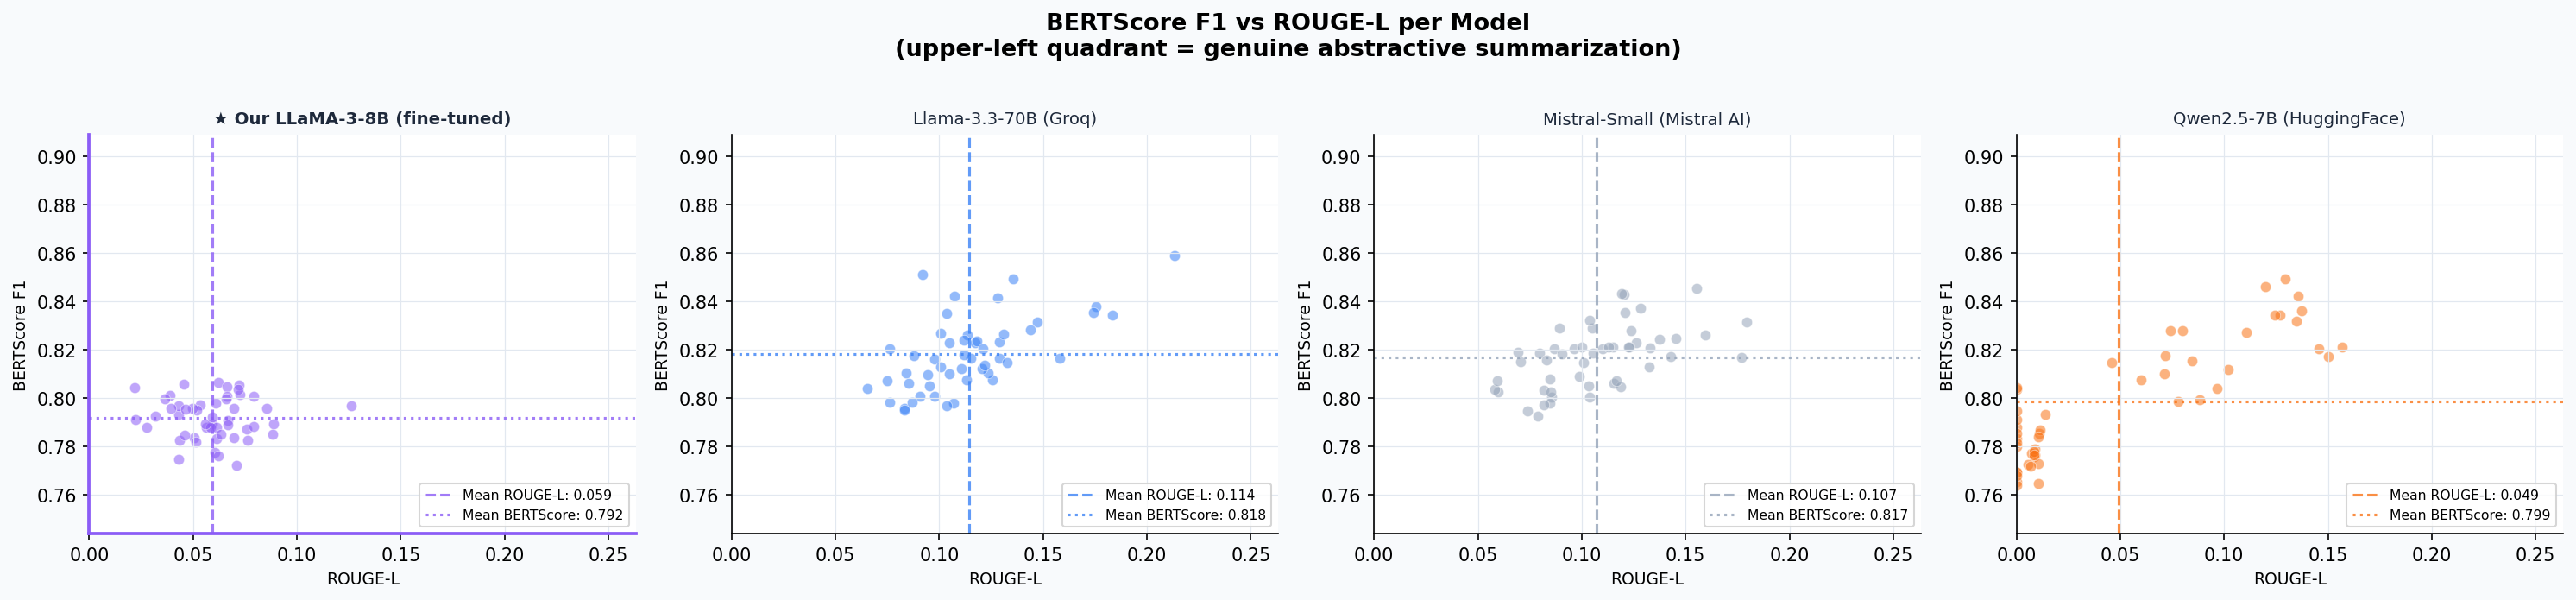

In [ ]:
n = len(model_order)
ncols = min(n, 4)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
if nrows == 1:
    axes = [axes] if ncols == 1 else list(axes)
else:
    axes = [ax for row in axes for ax in row]

fig.suptitle('BERTScore F1 vs ROUGE-L per Model\n'
             '(upper-left quadrant = genuine abstractive summarization)',
             fontsize=13, fontweight='bold', y=1.02)

# Find global axis limits for consistent comparison
all_rouge = [s for m in all_scores.values() for s in m['rouge_l']]
all_bert  = [s for m in all_scores.values() for s in m['bert_f1']]
xlim = (max(0, min(all_rouge) - 0.02), min(1, max(all_rouge) + 0.05))
ylim = (max(0, min(all_bert)  - 0.02), min(1, max(all_bert)  + 0.05))

for ax, model in zip(axes, model_order):
    color    = MODEL_COLORS.get(model, '#94A3B8')
    is_ours  = 'LLaMA' in model
    rouge_s  = all_scores[model]['rouge_l']
    bert_s   = all_scores[model]['bert_f1']
    m_rouge  = np.mean(rouge_s)
    m_bert   = np.mean(bert_s)

    ax.scatter(rouge_s, bert_s, color=color,
               alpha=0.55, s=35,
               edgecolors='white', linewidth=0.4)

    ax.axvline(m_rouge, color=color, linestyle='--', linewidth=1.5,
               alpha=0.8, label=f'Mean ROUGE-L: {m_rouge:.3f}')
    ax.axhline(m_bert,  color=color, linestyle=':',  linewidth=1.5,
               alpha=0.8, label=f'Mean BERTScore: {m_bert:.3f}')

    title = model.replace('\n', ' ')
    if is_ours:
        title = '★ ' + title
    ax.set_title(title, fontsize=9.5,
                 fontweight='bold' if is_ours else 'normal',
                 color='#1E293B')
    ax.set_xlabel('ROUGE-L', fontsize=9)
    ax.set_ylabel('BERTScore F1', fontsize=9)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.legend(fontsize=7.5, loc='lower right')

    if is_ours:
        for spine in ax.spines.values():
            spine.set_edgecolor('#8B5CF6')
            spine.set_linewidth(1.8)

# Hide unused axes
for ax in axes[len(model_order):]:
    ax.set_visible(False)

plt.tight_layout()
save_fig(fig, 'fig_comparison_C_scatter')
plt.show()

  💾 Saved: /content/drive/MyDrive/clinical_mas/results/figures/fig_comparison_A_bertscore_only.png


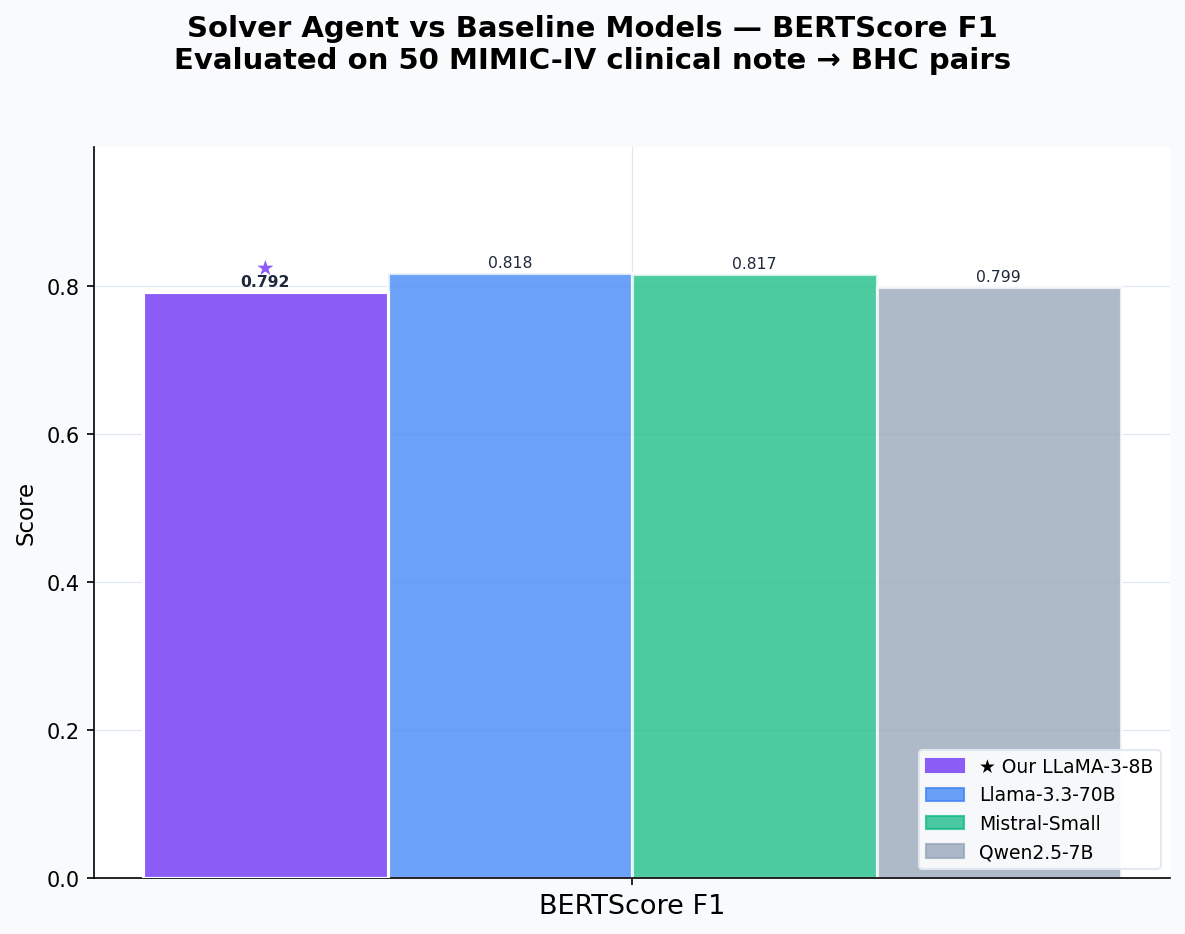

In [ ]:
# ── Figure A v2: BERTScore only, same style as original ──────────────────────
metric_key   = 'bert_f1'
metric_label = 'BERTScore F1'

n_models  = len(model_order)
bar_width = 0.18
offsets   = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * bar_width

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(
    'Solver Agent vs Baseline Models — BERTScore F1\n'
    f'Evaluated on {N_EVAL} MIMIC-IV clinical note → BHC pairs',
    fontsize=14, fontweight='bold', y=1.03
)

for i, model in enumerate(model_order):
    color   = MODEL_COLORS.get(model, '#94A3B8')
    is_ours = 'LLaMA' in model
    val     = np.mean(all_scores[model][metric_key])

    bar = ax.bar(
        0 + offsets[i], val,
        width=bar_width,
        color=color,
        alpha=1.0 if is_ours else 0.75,
        edgecolor='white',
        linewidth=1.5,
        label=model.replace('\n', ' '),
        zorder=3 if is_ours else 2,
    )

    ax.text(
        bar[0].get_x() + bar[0].get_width() / 2,
        val + 0.003,
        f'{val:.3f}',
        ha='center', va='bottom',
        fontsize=7.5,
        fontweight='bold' if is_ours else 'normal',
        color='#1E293B',
    )

    if is_ours:
        ax.text(
            bar[0].get_x() + bar[0].get_width() / 2,
            val + 0.018,
            '★',
            ha='center', va='bottom', fontsize=10, color=color,
        )

ax.set_xticks([0])
ax.set_xticklabels([metric_label], fontsize=13)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

handles = [
    mpatches.Patch(
        color=MODEL_COLORS.get(m, '#94A3B8'),
        alpha=1.0 if 'LLaMA' in m else 0.75,
        label=('★ ' if 'LLaMA' in m else '') + m.split('\n')[0]
    )
    for m in model_order
]
ax.legend(handles=handles, fontsize=9, loc='lower right',
          framealpha=0.9, edgecolor=COLORS['grid'])



plt.tight_layout()
save_fig(fig, 'fig_comparison_A_bertscore_only')
plt.show()

## Step 15 — Final Report

In [ ]:
print('=' * 72)
print('  MODEL COMPARISON — FINAL REPORT')
print(f'  Task: Clinical note → patient summary  |  n={N_EVAL} samples')
print(f'  Reference: physician-written BHC text')
print('=' * 72)
print(f'  {"Model":<38} {"BERTScore F1":>13}  {"ROUGE-L":>10}')
print('-' * 72)

# Sort by BERTScore
sorted_models = sorted(all_scores.keys(),
                       key=lambda m: np.mean(all_scores[m]['bert_f1']),
                       reverse=True)

for rank, model in enumerate(sorted_models, 1):
    b_mean = np.mean(all_scores[model]['bert_f1'])
    b_std  = np.std(all_scores[model]['bert_f1'])
    r_mean = np.mean(all_scores[model]['rouge_l'])
    r_std  = np.std(all_scores[model]['rouge_l'])
    marker = ' ◀ OUR MODEL' if 'LLaMA' in model else ''
    name   = model.replace('\n', ' ')
    print(f'  #{rank} {name:<36} {b_mean:.4f}±{b_std:.4f}  '
          f'{r_mean:.4f}±{r_std:.4f}{marker}')

print('=' * 72)
print()
print('  Figures saved:')
for fn in ['fig_comparison_A_grouped_bar.png',
            'fig_comparison_B_distributions.png',
            'fig_comparison_C_scatter.png']:
    icon = '✅' if os.path.exists(f'{FIGS_DIR}/{fn}') else '❌'
    print(f'    {icon} {fn}')
print('=' * 72)

  MODEL COMPARISON — FINAL REPORT
  Task: Clinical note → patient summary  |  n=50 samples
  Reference: physician-written BHC text
  Model                                   BERTScore F1     ROUGE-L
------------------------------------------------------------------------
  #1 Llama-3.3-70B (Groq)                 0.8182±0.0150  0.1141±0.0294
  #2 Mistral-Small (Mistral AI)           0.8170±0.0127  0.1071±0.0283
  #3 Qwen2.5-7B (HuggingFace)             0.7988±0.0244  0.0491±0.0544
  #4 Our LLaMA-3-8B (fine-tuned)          0.7919±0.0085  0.0593±0.0185 ◀ OUR MODEL

  Figures saved:
    ✅ fig_comparison_A_grouped_bar.png
    ✅ fig_comparison_B_distributions.png
    ✅ fig_comparison_C_scatter.png
